In [6]:
# -------------------------------------------------------------------------
#  Map:  dataset_name  ➜ { model_name ➜ path/to/results_cleaned_v2.csv }
#  Use absolute or relative paths.  Leave out models you don’t have.
# -------------------------------------------------------------------------
DATASETS = {
    "In-Domain Val": {
        "R1 Long":  "/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_val/responses/long_prompt_r1_0528/100genes/results_cleaned_v2.csv",
        "R1 Short": "/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_val/responses/short_prompt_r1_0528/100genes/results_cleaned_v2.csv",
        "V3 Long":  "/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_val/responses/long_prompt_v3/100genes/results_cleaned_v2.csv",
        "V3 Short": "/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_val/responses/short_prompt_v3/100genes/results_cleaned_v2.csv",
    },
    "In-Domain Test": {
        "scTab":  "/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/scTab/results_cleaned_v2.csv",
        "R1 (scGPT Classifier)":  "/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/long_prompt_r1_0528/500genes_scGPTClassifier/results_cleaned_v2.csv",
        "R1 (scTab Classifier)":  "/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/long_prompt_r1_0528/500genes_scTabClassifier/results_cleaned_v2.csv",
        "scGPT":  "/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/scGPT/results_cleaned_v2.csv",
        "R1":  "/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/long_prompt_r1_0528/500genes/results_cleaned_v2.csv",
        "C2S-Scale":  "/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/c2s_scale/200genes/prediction_results/results_cleaned_v2.csv",
    },
    "Random OOD": {
        "scTab":  "/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/scTab/results_cleaned_v2.csv",
        "R1 (scGPT Classifier)":  "/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/long_prompt_r1_0528/500genes_scGPTClassifier/results_cleaned_v2.csv",
        "R1 (scTab Classifier)":  "/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/long_prompt_r1_0528/500genes_scTabClassifier/results_cleaned_v2.csv",
        "scGPT":  "/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/scGPT/results_cleaned_v2.csv",
        "R1":  "/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/long_prompt_r1_0528/500genes/results_cleaned_v2.csv",
        "C2S-Scale":  "/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/c2s_scale/200genes/prediction_results/results_cleaned_v2.csv",
    },
}

In [7]:
import itertools, pathlib, csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
import os

In-Domain Val: 9,906 shared cells across 4 models
  ↳ long table -> In-Domain Val_pairwise_mcnemar.csv
  ↳ matrix      -> In-Domain Val_pvalue_matrix.csv


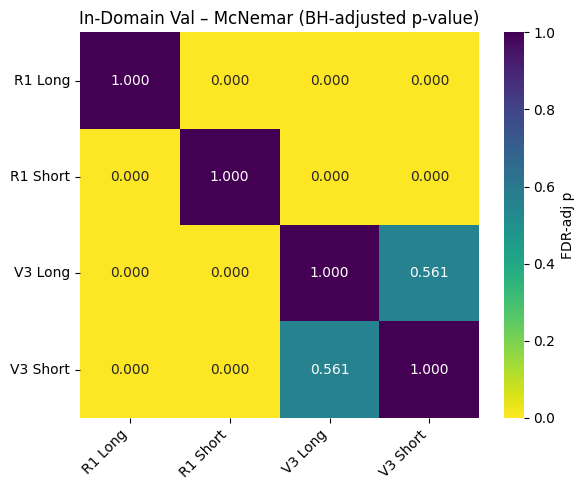

  ↳ figure      -> In-Domain Val_pvalue_heatmap.pdf 

In-Domain Test: 9,913 shared cells across 6 models
  ↳ long table -> In-Domain Test_pairwise_mcnemar.csv
  ↳ matrix      -> In-Domain Test_pvalue_matrix.csv


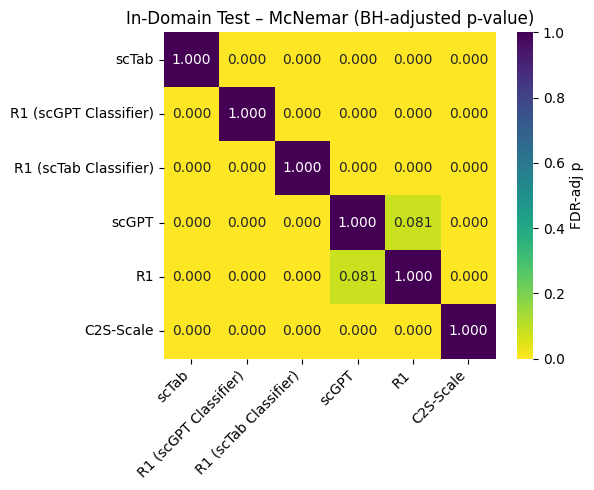

  ↳ figure      -> In-Domain Test_pvalue_heatmap.pdf 

Random OOD: 9,969 shared cells across 6 models
  ↳ long table -> Random OOD_pairwise_mcnemar.csv
  ↳ matrix      -> Random OOD_pvalue_matrix.csv


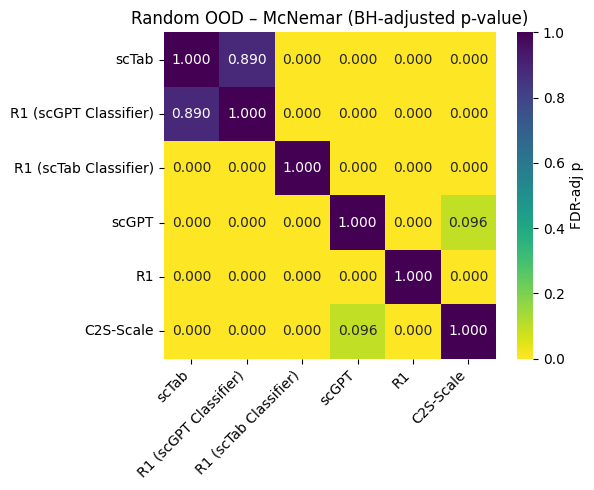

  ↳ figure      -> Random OOD_pvalue_heatmap.pdf 



In [8]:
# -------------------------------------------------------------
# 2) RUN THE REST UNCHANGED
# -------------------------------------------------------------


OUT = pathlib.Path("/cristealab/xiwang/DSR1_Preprint/Outputs/stats_tests")
OUT.mkdir(exist_ok=True, parents=True)


def load_match(csv_path):
    """Return Boolean Series indexed by cell id (TRUE if correct)."""
    df = pd.read_csv(csv_path)
    df = df[df["cell"] != "EVALUATION_METRICS"]          # drop metric block
    return pd.Series(
        (df["match_scTab"].astype(str).str.upper() == "TRUE").values,
        index=df["cell"].astype(str),
    )


for dset, models_paths in DATASETS.items():
    # ---------- load & align ----------
    ser = {m: load_match(p) for m, p in models_paths.items()}
    common = set.intersection(*(set(s.index) for s in ser.values()))
    ser = {m: s.loc[sorted(common)].astype(bool) for m, s in ser.items()}
    print(f"{dset}: {len(common):,} shared cells across {len(ser)} models")

    # ---------- pairwise McNemar ----------
    pair_records = []
    for a, b in itertools.combinations(ser, 2):
        both = pd.DataFrame({a: ser[a], b: ser[b]})
        n01 = ((~both[a]) &  both[b]).sum()
        n10 = ( both[a]  & (~both[b])).sum()
        p   = mcnemar([[0, n01], [n10, 0]], exact=True).pvalue \
              if (n01 + n10) else 1.0
        pair_records.append(dict(model_A=a, model_B=b,
                                 n01=n01, n10=n10, p_exact=p))

    pair_df = pd.DataFrame(pair_records)

    # FDR (Benjamini–Hochberg) across all pairs *within this dataset*
    pair_df["p_adj_FDR"] = multipletests(pair_df["p_exact"],
                                         method="fdr_bh")[1]
    pair_df.sort_values("p_adj_FDR", inplace=True)

    # ---------- save long table ----------
    long_path = OUT / f"{dset}_pairwise_mcnemar.csv"
    pair_df.to_csv(long_path, index=False)
    print("  ↳ long table ->", long_path.name)

    # ---------- build symmetric matrix ----------
    models = list(ser)
    mat = pd.DataFrame(1.0, index=models, columns=models, dtype=float)
    for _, row in pair_df.iterrows():
        mat.loc[row["model_A"], row["model_B"]] = row["p_adj_FDR"]
        mat.loc[row["model_B"], row["model_A"]] = row["p_adj_FDR"]

    wide_path = OUT / f"{dset}_pvalue_matrix.csv"
    mat.to_csv(wide_path)
    print("  ↳ matrix      ->", wide_path.name)

    # ---------- heat-map ----------
    plt.figure(figsize=(6, 5))
    sns.heatmap(mat, annot=True, fmt=".3f",
                cmap="viridis_r", vmin=0, vmax=1,
                cbar_kws={"label": "FDR-adj p"})
    plt.title(f"{dset} – McNemar (BH-adjusted p-value)")
    plt.yticks(rotation=0)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    pdf_path = OUT / f"{dset}_pvalue_heatmap.pdf"
    plt.savefig(pdf_path)
    plt.show()
    print("  ↳ figure      ->", pdf_path.name, "\n")

macro F1

In [9]:
# -------------------------------------------------------------
# 3-bis) macro-F1 helper
# -------------------------------------------------------------
from collections import Counter

def macro_f1(gt, pred):
    """
    Compute macro-F1 in pure numpy (no sklearn dependency).
    gt, pred : 1-D arrays of str labels of equal length.
    """
    labels = np.unique(gt)                     # only GT labels count
    tp = Counter()
    fp = Counter()
    fn = Counter()
    for g, p in zip(gt, pred):
        if p == g:
            tp[g] += 1
        else:
            fn[g] += 1
            if p in labels:
                fp[p] += 1
    f1s = []
    for lab in labels:
        t, f_p, f_n = tp[lab], fp[lab], fn[lab]
        prec = t / (t + f_p) if t + f_p else 0.0
        rec  = t / (t + f_n) if t + f_n else 0.0
        f1   = 2*prec*rec/(prec+rec) if prec+rec else 0.0
        f1s.append(f1)
    return float(np.mean(f1s))

def paired_boot_p(gt, preds_A, preds_B, n_boot=10_000, seed=0):
    """
    gt         : ndarray ground-truth labels
    preds_A/B  : ndarray predictions of two models
    returns    : two-sided p-value for H0: macroF1_A == macroF1_B
    """
    rng = np.random.default_rng(seed)
    n   = len(gt)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx   = rng.integers(0, n, size=n)
        diff  = (macro_f1(gt[idx], preds_A[idx])
                 - macro_f1(gt[idx], preds_B[idx]))
        diffs[i] = diff
    p = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    return p

In-Domain Val macro-F1 pairs:   0%|          | 0/6 [00:00<?, ?it/s]

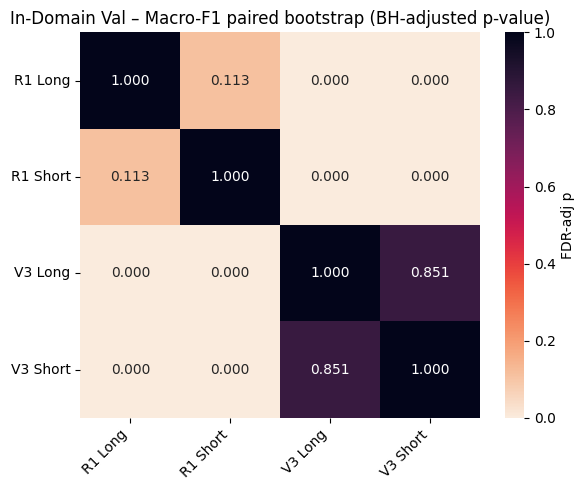

In-Domain Test macro-F1 pairs:   0%|          | 0/15 [00:00<?, ?it/s]

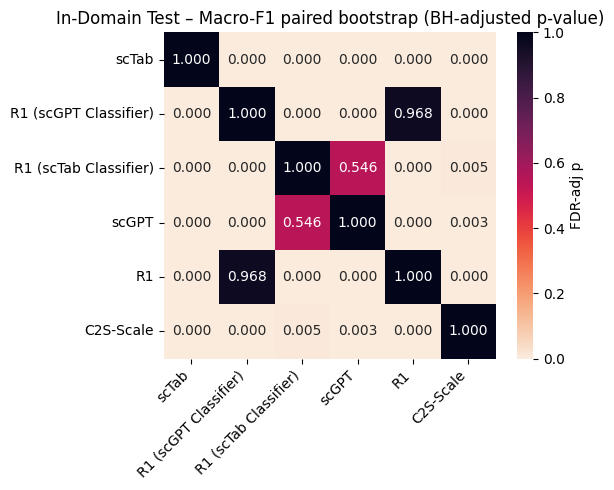

Random OOD macro-F1 pairs:   0%|          | 0/15 [00:00<?, ?it/s]

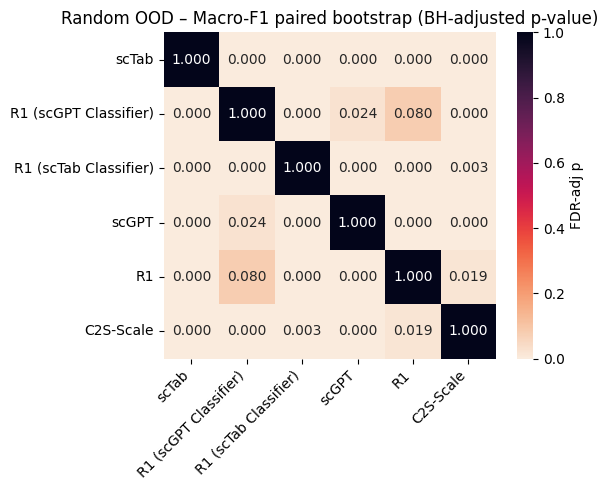

In [10]:
# -------------------------------------------------------------
# 4-bis)  Paired-bootstrap macro-F1  **with progress bars**
# -------------------------------------------------------------
from collections import Counter
from tqdm.auto import tqdm               # ← NEW
from joblib import Parallel, delayed

def macro_f1(gt, pred):
    """Macro-F1 using only labels present in ground truth."""
    labels = np.unique(gt)
    tp = Counter(); fp = Counter(); fn = Counter()
    for g, p in zip(gt, pred):
        if p == g:
            tp[g] += 1
        else:
            fn[g] += 1
            if p in labels:
                fp[p] += 1
    f1s = []
    for lab in labels:
        t, f_p, f_n = tp[lab], fp[lab], fn[lab]
        prec = t / (t + f_p) if t + f_p else 0.0
        rec  = t / (t + f_n) if t + f_n else 0.0
        f1s.append(2*prec*rec/(prec+rec) if prec+rec else 0.0)
    return float(np.mean(f1s))

def paired_boot_p(gt, preds_A, preds_B, n_boot=10_000, seed=0):
    """Two-sided paired bootstrap p-value for macro-F1."""
    rng = np.random.default_rng(seed)
    n   = len(gt)
    diffs = np.empty(n_boot)
    for i in tqdm(range(n_boot), leave=False, desc="boot"):
        idx        = rng.integers(0, n, size=n)
        diffs[i]   = (macro_f1(gt[idx], preds_A[idx]) -
                      macro_f1(gt[idx], preds_B[idx]))
    return 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())

def paired_bootstrap_p_parallel(
    gt, preds_A, preds_B, n_boot=10_000, n_jobs=-1, seed=0
):
    """Two-sided paired bootstrap p-value for macro-F1 optimized for parallel execution."""
    rng = np.random.default_rng(seed)
    n = len(gt)
    delta_obs = macro_f1(gt, preds_A) - macro_f1(gt, preds_B)
    
    # produce bootstrap indices all at once to avoid repeated rng calls
    bootstrap_indices = [rng.integers(0, n, size=n) for _ in range(n_boot)]
    
    # 并行计算
    diffs = Parallel(n_jobs=n_jobs)(
        delayed(lambda idx: macro_f1(gt[idx], preds_A[idx]) - macro_f1(gt[idx], preds_B[idx]))(idx)
        for idx in bootstrap_indices
    )
    diffs = np.array(diffs)
    return 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())

for dset, model_paths in DATASETS.items():

    # ---------- load GT + predictions ----------
    df_models = {}
    for m, path in model_paths.items():
        df = pd.read_csv(path)
        df = df[df["cell"] != "EVALUATION_METRICS"]
        df.set_index("cell", inplace=True)
        df_models[m] = df[["ground_truth_label", "predicted_label"]]

    common_ids = set.intersection(*(set(df.index) for df in df_models.values()))
    gt_arr = df_models[next(iter(df_models))].loc[sorted(common_ids),
                                                  "ground_truth_label"].to_numpy()
    preds = {m: df.loc[sorted(common_ids), "predicted_label"].to_numpy()
             for m, df in df_models.items()}

    # ---------- paired bootstrap over all model pairs ----------
    f1_records = []
    pairs_iter = itertools.combinations(preds, 2)
    for a, b in tqdm(list(pairs_iter), desc=f"{dset} macro-F1 pairs"):
        p = paired_bootstrap_p_parallel(gt_arr, preds[a], preds[b],
                          n_boot=10_000, seed=0)
        f1_records.append(dict(model_A=a, model_B=b, p_exact=p))

    f1_df = pd.DataFrame(f1_records)
    f1_df["p_adj_FDR"] = multipletests(f1_df["p_exact"],
                                       method="fdr_bh")[1]
    f1_df.sort_values("p_adj_FDR", inplace=True)

    # ---------- save long table ----------
    f1_long = OUT / f"{dset}_pairwise_macroF1.csv"
    f1_df.to_csv(f1_long, index=False)

    # ---------- symmetric matrix & heat-map ----------
    models = list(preds)
    mat = pd.DataFrame(1.0, index=models, columns=models)
    for _, row in f1_df.iterrows():
        mat.loc[row["model_A"], row["model_B"]] = row["p_adj_FDR"]
        mat.loc[row["model_B"], row["model_A"]] = row["p_adj_FDR"]
    mat.to_csv(OUT / f"{dset}_macroF1_matrix.csv")

    plt.figure(figsize=(6,5))
    sns.heatmap(mat, annot=True, fmt=".3f",
                cmap="rocket_r", vmin=0, vmax=1,
                cbar_kws={"label": "FDR-adj p"})
    plt.title(f"{dset} – Macro-F1 paired bootstrap (BH-adjusted p-value)")
    plt.yticks(rotation=0)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUT / f"{dset}_macroF1_heatmap.pdf")
    plt.show()

In [11]:
# merge results into a supplementary table
from pathlib import Path
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter

# --------- input files ---------
csv_files = [
    '/cristealab/xiwang/DSR1_Preprint/Outputs/stats_tests/In-Domain Test_pairwise_macroF1.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/stats_tests/In-Domain Test_pairwise_mcnemar.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/stats_tests/In-Domain Val_pairwise_macroF1.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/stats_tests/In-Domain Val_pairwise_mcnemar.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/stats_tests/Random OOD_pairwise_macroF1.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/stats_tests/Random OOD_pairwise_mcnemar.csv',
]

out_dir  = Path('/cristealab/xiwang/DSR1_Preprint/Outputs/supplementary_table')
out_dir.mkdir(parents=True, exist_ok=True)           
out_path = out_dir / 'pairwise_pvalues.xlsx'

# --------- output Excel（pandas → openpyxl）---------
with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        # set tab names
        stem = Path(csv_file).stem
        sheet_name = stem.replace('_pairwise_', ' ')[:31]
        df.to_excel(writer, sheet_name=sheet_name, index=False)

# --------- adjust cell width（openpyxl）---------
wb = load_workbook(out_path)

for ws in wb.worksheets:
    #  set width of each column by header length
    for col_idx, cell in enumerate(ws[1], 1):           # enumerate from·1
        header = str(cell.value) if cell.value is not None else ''
        min_width = len(header) + 2                      
        col_letter = get_column_letter(col_idx)
        current_width = ws.column_dimensions[col_letter].width
        if current_width is None or current_width < min_width:
            ws.column_dimensions[col_letter].width = min_width

wb.save(out_path)
print(f'✅ Output: {out_path}')

✅ Output: /cristealab/xiwang/DSR1_Preprint/Outputs/supplementary_table/pairwise_pvalues.xlsx
